[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [21]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Para serializar el modelo
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

# Carga de la nueva base de datos
df = pd.read_csv('myntra_products_catalog.csv')
print(f'Dataset cargado — {df.shape[0]} registros, {df.shape[1]} columnas')

df.head()

---
## 3. Etapa 2 — Exploración y preparación de datos

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 12491 entries, 0 to 12490
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ProductID     12491 non-null  int64
 1   ProductName   12491 non-null  str  
 2   ProductBrand  12491 non-null  str  
 3   Gender        12491 non-null  str  
 4   Price (INR)   12491 non-null  int64
 5   NumImages     12491 non-null  int64
 6   Description   12491 non-null  str  
 7   PrimaryColor  12491 non-null  str  
dtypes: int64(3), str(5)
memory usage: 780.8 KB

Valores nulos por columna:
ProductID       0
ProductName     0
ProductBrand    0
Gender          0
Price (INR)     0
NumImages       0
Description     0
PrimaryColor    0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 12491


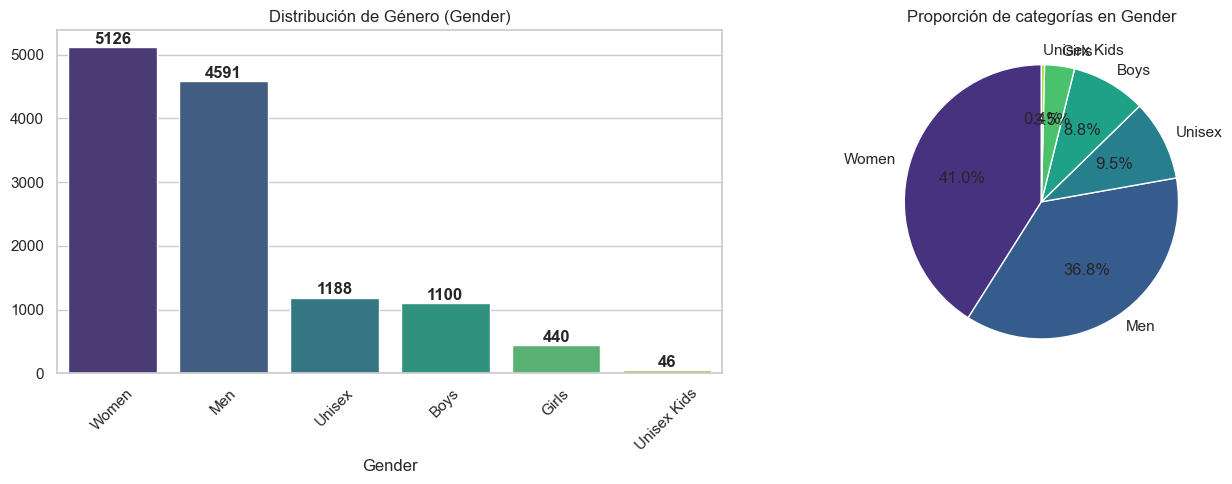

In [22]:
# 3.1 y 3.2 Información y limpieza
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()

print('\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Limpiamos duplicados y rellenamos nulos en el color
df = df.drop_duplicates().reset_index(drop=True)
df['PrimaryColor'] = df['PrimaryColor'].fillna('Unknown')
print(f'Registros después de limpieza: {df.shape[0]}')

# 3.3 Distribución de la variable objetivo ('Gender')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gender_counts = df['Gender'].value_counts()

sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], hue=gender_counts.index, palette='viridis', legend=False)
axes[0].set_title('Distribución de Género (Gender)')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(gender_counts)))
axes[1].set_title('Proporción de categorías en Gender')

plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [23]:
# 4.1 Selección de features y target
features_categoricas = ['ProductBrand', 'PrimaryColor']
features_numericas = ['Price (INR)', 'NumImages']

X = df[features_categoricas + features_numericas]
y = df['Gender']

print(f'Features: {X.shape}')   
print(f'Target (Gender): {y.shape}')   

# 4.2 División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

# 4.3 Preprocesamiento mediante ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categoricas)
    ]
)

Features: (12491, 4)
Target (Gender): (12491,)
Train: 9992 muestras
Test:  2499 muestras


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [24]:
# 5.1 Definición de pipelines adaptados
pipelines = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=10, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
    ])
}

# 5.2 Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    print(f'Entrenando {name}...')
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s} Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}\n')

Entrenando LogisticRegression...
LogisticRegression        Accuracy CV: 0.8514 ± 0.0074

Entrenando DecisionTree...
DecisionTree              Accuracy CV: 0.6156 ± 0.0123

Entrenando RandomForest...
RandomForest              Accuracy CV: 0.6605 ± 0.0182



---
## 6. Etapa 5 — Evaluación del mejor modelo

Entrenando el mejor modelo (LogisticRegression) con el set de entrenamiento completo...

Mejor modelo: LogisticRegression
Accuracy en test: 0.8651

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Boys       0.74      0.75      0.74       220
       Girls       0.73      0.36      0.48        88
         Men       0.85      0.90      0.87       918
      Unisex       0.88      0.82      0.85       238
 Unisex Kids       0.86      0.67      0.75         9
       Women       0.91      0.92      0.91      1026

    accuracy                           0.87      2499
   macro avg       0.83      0.73      0.77      2499
weighted avg       0.86      0.87      0.86      2499



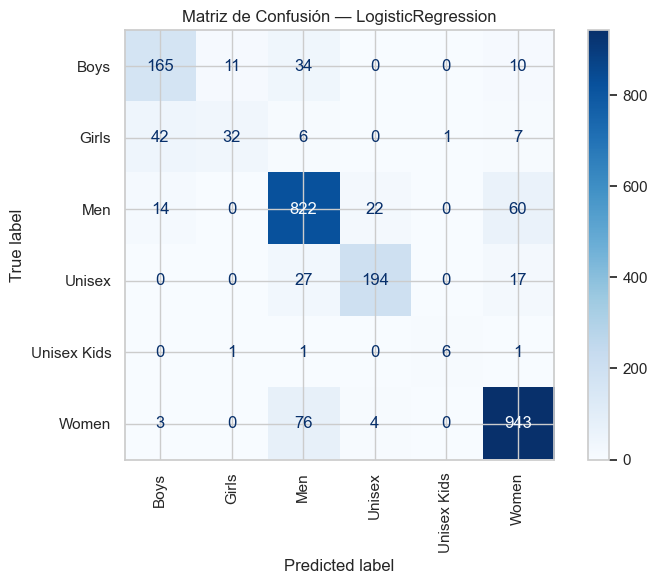

In [25]:
# 6.1 Seleccionar el mejor modelo según CV y entrenar
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]

print(f'Entrenando el mejor modelo ({best_name}) con el set de entrenamiento completo...')
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'\nMejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')

# 6.2 Reporte de Clasificación
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred))

# 6.3 Matriz de confusión visual
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', ax=ax, xticks_rotation='vertical'
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [26]:
# 7.1 Guardar el modelo
MODEL_PATH = 'catalogo_gender_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}\n')

# 7.2 Función de inferencia simulada
def predecir_genero_producto(datos_producto: dict) -> dict:
    modelo_cargado = joblib.load(MODEL_PATH)
    input_df = pd.DataFrame([datos_producto])
    
    pred = modelo_cargado.predict(input_df)[0]
    
    try:
        proba = modelo_cargado.predict_proba(input_df)[0]
        probabilidades = dict(zip(modelo_cargado.classes_, np.round(proba, 4)))
    except AttributeError:
        probabilidades = "El modelo no soporta probabilidades detalladas"

    return {
        'prediccion_genero': pred,
        'probabilidades': probabilidades
    }

# 7.3 Ejemplo de uso con datos nuevos
producto_ejemplo = {
    'ProductBrand': 'SPYKAR',
    'PrimaryColor': 'Pink',
    'Price (INR)': 1200,
    'NumImages': 4
}

resultado = predecir_genero_producto(producto_ejemplo)

print('--- Resultado de la inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')

Modelo guardado en: catalogo_gender_model.joblib

--- Resultado de la inferencia ---
  prediccion_genero: Women
  probabilidades: {'Boys': np.float64(0.0104), 'Girls': np.float64(0.0104), 'Men': np.float64(0.0216), 'Unisex': np.float64(0.0184), 'Unisex Kids': np.float64(0.0022), 'Women': np.float64(0.9371)}


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

In [ ]:
#Ejercicio 1
from sklearn.model_selection import GridSearchCV

# 1. Definir la grilla de hiperparámetros para RandomForest (prefijo clf__)
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10]
}

# 2. Configurar GridSearchCV
# Usamos n_jobs=-1 para paralelizar el proceso y acelerar la búsqueda
grid_search = GridSearchCV(
    estimator=pipelines['RandomForest'], 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

print("Buscando los mejores hiperparámetros para RandomForest...")
grid_search.fit(X_train, y_train)

# 3. Mostrar los resultados
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor accuracy en Validación Cruzada: {grid_search.best_score_:.4f}")

# 4. Evaluación del modelo optimizado en el set de prueba
rf_optimizado = grid_search.best_estimator_
accuracy_test_rf = rf_optimizado.score(X_test, y_test)
print(f"Accuracy en Test (RF Optimizado): {accuracy_test_rf:.4f}")

In [ ]:
#Ejercicio 2
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report

# 1. Recolección
data = load_breast_cancer(as_frame=True)
X_bc = data.data
y_bc = data.target

# 2. Preparación (División estratificada)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.20, random_state=42, stratify=y_bc
)

# 3. Preprocesamiento (Solo estandarización ya que no hay variables categóricas)
preprocessor_bc = StandardScaler()

# 4. Pipeline y Entrenamiento (Usamos Logistic Regression como modelo base)
pipeline_bc = Pipeline([
    ('scaler', preprocessor_bc),
    ('clf', LogisticRegression(random_state=42))
])

print("Entrenando modelo para Breast Cancer Wisconsin...")
pipeline_bc.fit(X_train_bc, y_train_bc)

# 5. Evaluación
y_pred_bc = pipeline_bc.predict(X_test_bc)
print("\n--- Resultados Breast Cancer ---")
print(f"Accuracy en test: {accuracy_score(y_test_bc, y_pred_bc):.4f}\n")
print(classification_report(y_test_bc, y_pred_bc))

In [ ]:
#Ejercicio 3
# !pip install mlflow
import mlflow
import mlflow.sklearn

# 1. Configurar el experimento en MLflow
mlflow.set_experiment("Optimizacion_Myntra_Catalog")

# 2. Iniciar el registro de la ejecución
with mlflow.start_run(run_name="RandomForest_GridSearch"):
    
    # Registrar los mejores hiperparámetros encontrados en el Ejercicio 1
    mlflow.log_params(grid_search.best_params_)
    
    # Registrar la métrica de rendimiento final
    mlflow.log_metric("accuracy_test", accuracy_test_rf)
    
    # Guardar el modelo serializado dentro del entorno de MLflow
    mlflow.sklearn.log_model(rf_optimizado, "modelo_random_forest")
    
    print("Experimento y modelo registrados exitosamente en MLflow.")

# Nota: Para ver la interfaz de MLflow, ejecuta en la terminal o en otra celda:
# !mlflow ui

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*